In [33]:
import sys
import os

sys.path.append(os.path.abspath(".."))

In [34]:
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from SupernovaDataset_H0.dataset_creation import create_synthetic_supernovae_dataset, create_torch_supernovae_dataset, z_obs

from SupernovaDataset_H0.config import DATAPOINT_SIZE, LATENT_SIZE, DATA_VARIANCE_SCALE
from SupernovaDataset_H0.config import NUM_TRAIN, NUM_TEST, LOAD_DATASET
from SupernovaDataset_H0.config import BETA, REGULARIZATION_WEIGHT, LEARNING_RATE, OPTIM, NUM_EPOCHS, BATCH_SIZE

from Compression.ib import IB
from Compression.compressors import IBCompressor
from Compression.conditional_prob_models import ConditionalKDE, ConditionalNormalizingFlow
from Compression.mine import Mine

from Compression.Benchmarks.MOPED import moped

from ModelEvaluation.posterior_comparison import evaluate_posterior_covariance
from ModelEvaluation.abc import abc_testing
from ModelEvaluation.coverage_testing import coverage_tests

In [35]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Running on device:", device)

Running on device: cuda


In [36]:
print(torch.__version__)
print(torch.version.cuda)
print(torch.cuda.is_available())

2.12.0+cu132
13.2
True


In [37]:
class Bounds():
    def __init__(self, name, cond_prob_model_class, **kwargs):
        self.name = name
        self.cond_prob_model = cond_prob_model_class
        self.cond_prob_model_kwargs = kwargs

In [38]:
# BOUND_USED = Bounds(name="BA_KDE", cond_prob_model_class=ConditionalKDE, **{"init_std": 1, "num_kde_points": 10})
BOUND_USED = Bounds(name="BA_NF", cond_prob_model_class=ConditionalNormalizingFlow, **{"num_flows": 8})
# BOUND_USED = Bounds(name="MINE", cond_prob_model_class=Mine, **{"y_dim": 1, "z_dim": LATENT_SIZE, "alpha": 1e-2})


## Generating a dataset

In [39]:
# LOAD_DATASET = False

In [40]:
if LOAD_DATASET:
    try:
        train_sims_data = torch.load("train_sims_data.pt")
        test_sims_data = torch.load("test_sims_data.pt")
    except FileNotFoundError:
        print("Data files not found. Creating dataset...")
        train_sims_data, test_sims_data, _ = create_torch_supernovae_dataset(NUM_TRAIN, NUM_TEST)
        torch.save(train_sims_data.to('cpu'), "train_sims_data.pt")
        torch.save(test_sims_data.to('cpu'), "test_sims_data.pt")
else:
    train_sims_data, test_sims_data, _ = create_torch_supernovae_dataset(NUM_TRAIN, NUM_TEST)
    torch.save(train_sims_data.to('cpu'), "train_sims_data.pt")
    torch.save(test_sims_data.to('cpu'), "test_sims_data.pt")

train_sims_data = train_sims_data.to(device)
test_sims_data = test_sims_data.to(device)

Data files not found. Creating dataset...
Creating sample: 10000 of 10000
Creating sample: 50000 of 50000


## Visualizing the dataset

### Spread of the data with Hubble Parameter
In order to visualize the fact that our data simply moves by a global offset based on the Hubble Constant, we visualize the mean of the data with the Hubble Parameter. This forms quite a linear scatter, showing that the mean is a good representation of the parameter here!

### Each individual datapoint
Each individual datapoint retains the same shape, and only its offset depends on the Hubble constant (can be seen by re-running the cell multiple times and seeing that the shape is retained...alternatively, I can plot all the data-points and subtract their means)  
We notice that the points at low redshift scatter less than those at higher redshifts. This is expected as the lower flux due to the higher redshift appears as a larger scatter

In [41]:
mu = train_sims_data[:, :DATAPOINT_SIZE].detach().cpu()
h0 = train_sims_data[:, -1].detach().cpu()

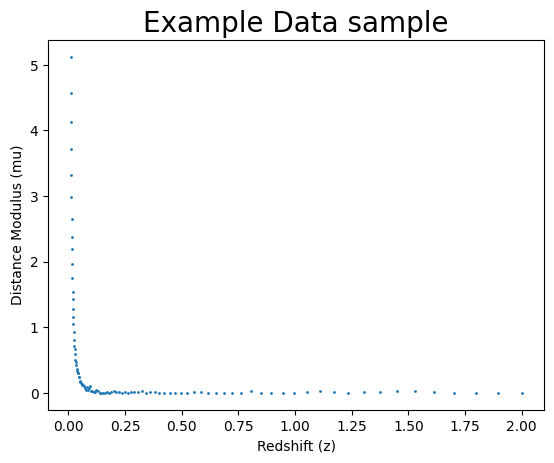

In [42]:
obs_no = np.random.randint(NUM_TRAIN)
flux_obs = 10**(-0.4*mu[obs_no, :])
mu_obs = mu[obs_no, :]
plt.scatter(z_obs, mu_obs, s=1)
# plt.scatter(z_obs, mu_noiseless[obs_no, :], color='red', label='True Signal')
plt.xlabel("Redshift (z)")
plt.ylabel("Distance Modulus (mu)")
# plt.title(f"Obs: {obs_no} | H0: {h0[obs_no]:.2f}")
plt.title('Example Data sample', fontsize=20)
plt.show()

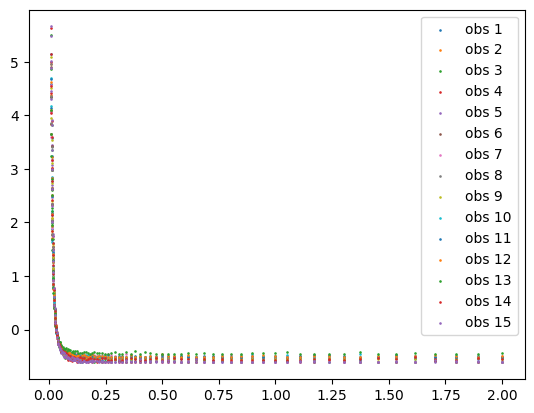

In [43]:
mu_zero_mean = mu - torch.mean(mu, axis=1)[:, None]
mu_zero_mean.shape

for i in range(15):
    plt.scatter(z_obs, mu_zero_mean[i, :], s=0.75, label=f'obs {i+1}')
plt.legend()
plt.show()

## Compression

In [44]:
class Compressor(nn.Module):
    def __init__(self, input_size=DATAPOINT_SIZE, latent_size=LATENT_SIZE):
        super(Compressor, self).__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_size, 1024),
            nn.LeakyReLU(0.2),

            nn.Linear(1024, 512),
            nn.LeakyReLU(0.2),

            nn.Linear(512, 512),
            nn.LeakyReLU(0.2),

            nn.Linear(512, 512),
            nn.LeakyReLU(0.2),

            nn.Linear(512, 64),
            nn.LeakyReLU(0.2),

            nn.Linear(64, 32),
            nn.LeakyReLU(0.2),
            
            nn.Linear(32, 2*latent_size)
        )

    def forward(self, x):
        return self.encoder(x)

In [45]:
model_encoder=Compressor()
model = IB(
    encoder=IBCompressor(encoder=model_encoder, x_dim=DATAPOINT_SIZE, z_dim=LATENT_SIZE),
    # cond_prob_model=ConditionalKDE(1, 2),
    # cond_prob_model=Mine(1, LATENT_SIZE, alpha=5e-1),
    cond_prob_model=BOUND_USED.cond_prob_model(**BOUND_USED.cond_prob_model_kwargs),
    beta = 1e-1,
    reg_weight=4e-2,
    reg_type=0,
    optim_func=torch.optim.Adam,
    lr=1e-4
).to(device)
h0s = train_sims_data[:, -1:]
h0_norm = (h0s - h0s.mean()) / h0s.std()

Epoch 1: Loss=3.6777, log_q=-3.5870,, reg. loss=0.0391, beta * KL=0.5159
Epoch 10: Loss=0.5988, log_q=-0.4897,, reg. loss=0.0108, beta * KL=0.9835
Epoch 20: Loss=-0.0813, log_q=0.3044,, reg. loss=0.0267, beta * KL=1.9639
Epoch 30: Loss=-1.0730, log_q=1.4780,, reg. loss=0.0351, beta * KL=3.6985
Epoch 40: Loss=-1.3316, log_q=1.7499,, reg. loss=0.0346, beta * KL=3.8378
Epoch 50: Loss=-1.4197, log_q=1.8956,, reg. loss=0.0341, beta * KL=4.4186


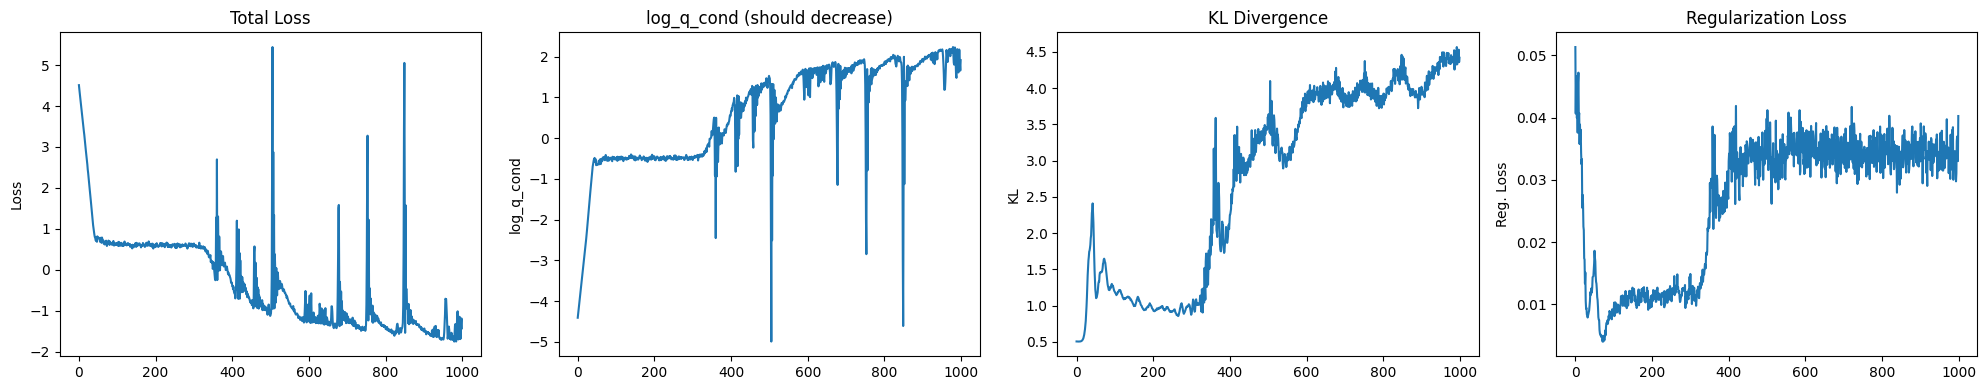

In [46]:
model.train(
    x_train=train_sims_data[:, :DATAPOINT_SIZE],
    y_train=h0_norm,
    nepochs=50,
    batch_size=512,
    print_losses=True
    )

assert not np.isnan(model.full_losses[-1]), "Total loss is NaN. Check the model and training process."

In [47]:
zs = model(test_sims_data[:, :DATAPOINT_SIZE]).detach().cpu()
z_min = zs.min()
z_max = zs.max()

print(f"Latent space range: min={z_min:.4f}, max={z_max:.4f}")

z_values = torch.linspace(z_min, z_max, 500)
y_values = torch.linspace(69.8**2, 70.2**2, 500)
yz_values = torch.cartesian_prod(z_values, y_values).to(device)
mine_values = model.cond_prob_model(yz_values[:, 1:], yz_values[:, 0:1]).detach().cpu().numpy()

Latent space range: min=-4.7034, max=2.4429


(array([  4.,   8.,  11.,  10.,   8.,  19., 325.,  78., 183., 354.]),
 array([-4.99203396, -4.26940863, -3.5467833 , -2.82415798, -2.10153265,
        -1.37890732, -0.656282  ,  0.06634333,  0.78896866,  1.51159399,
         2.23421931]),
 <BarContainer object of 10 artists>)

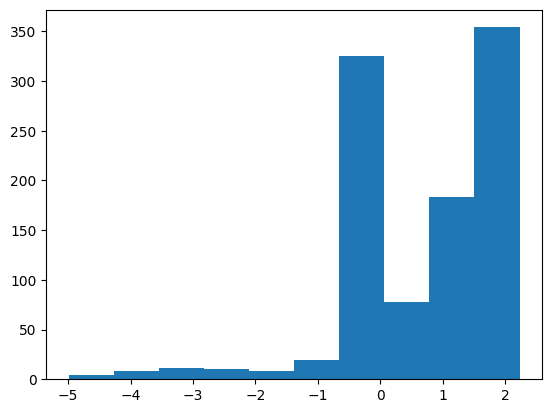

In [48]:
plt.hist(model.log_prob_losses)

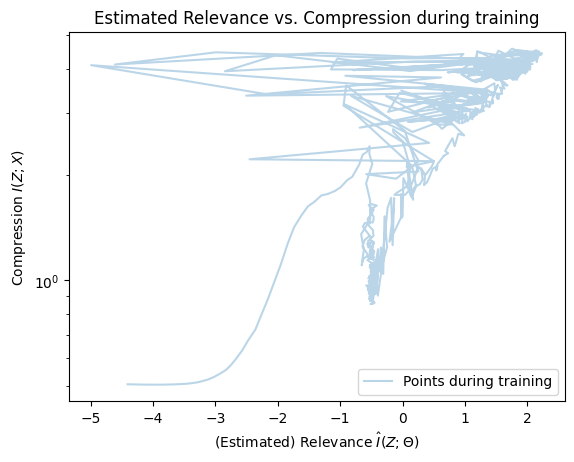

In [49]:
plt.plot(np.array(model.log_prob_losses), np.array(model.kl_losses), alpha=0.3, # s=5e0,
            label='Points during training')
# plt.axvline(
#     x = 8.64,
#     color='red',
#     linestyle='--',
#     linewidth=1,
#     label=r'Full dataset $I(X; \Theta)$'
# )
# plt.axvline(
#     x = 8.64 - 3.02,
#     color='green',
#     linestyle='--',
#     linewidth=1,
#     label=r'Expected model to learn $\hat{I}(X; \Theta)$'
# )

plt.yscale('log')
plt.xlabel(r"(Estimated) Relevance $\hat{I}(Z;\Theta)$")
plt.ylabel(r"Compression $I(Z;X)$")
plt.legend()
plt.title('Estimated Relevance vs. Compression during training')
plt.show()

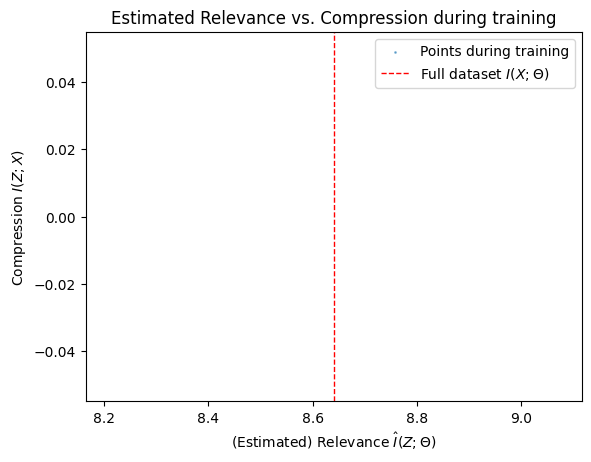

In [65]:
bounds = []
i_z_x = []
for i in range(0):
    print(f"Training new model iteration {i+1}...")
    model_encoder=Compressor()
    model = IB(
        encoder=IBCompressor(encoder=model_encoder, x_dim=DATAPOINT_SIZE, z_dim=LATENT_SIZE),
        cond_prob_model=BOUND_USED.cond_prob_model(**BOUND_USED.cond_prob_model_kwargs),
        beta = BETA,
        reg_weight=REGULARIZATION_WEIGHT,
        reg_type=0,
        optim_func=OPTIM,
        lr=LEARNING_RATE
    ).to(device)

    model.train(
        x_train=train_sims_data[:, :DATAPOINT_SIZE],
        y_train=h0_norm,
        nepochs=NUM_EPOCHS,
        batch_size=BATCH_SIZE,
        print_losses=True
        )
    assert not np.isnan(model.full_losses[-1]), "Total loss is NaN. Check the model and training process."

    bounds = bounds + model.log_prob_losses
    i_z_x = i_z_x + model.kl_losses

plt.scatter(-1*np.array(bounds), i_z_x, alpha=0.5, s=1e0,
            label='Points during training')
plt.axvline(
    x = 8.64,
    color='red',
    linestyle='--',
    linewidth=1,
    label=r'Full dataset $I(X; \Theta)$'
)
plt.xlabel(r"(Estimated) Relevance $\hat{I}(Z;\Theta)$")
plt.ylabel(r"Compression $I(Z;X)$")
plt.legend()
plt.title('Estimated Relevance vs. Compression during training')
plt.show()

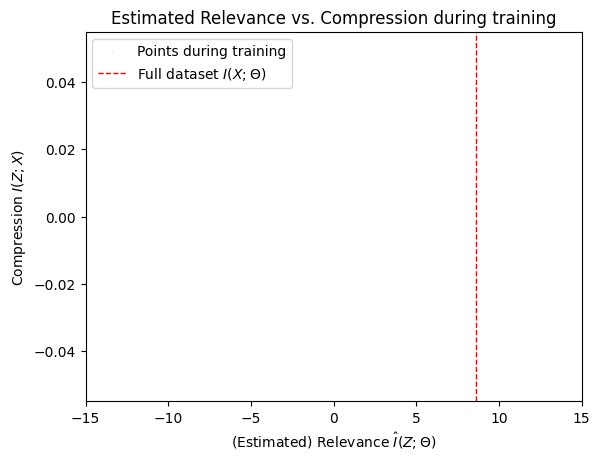

In [66]:
plt.scatter(np.array(bounds), i_z_x, alpha=0.5, s=1e-2,
            label='Points during training')
plt.axvline(
    x = 8.64,
    color='red',
    linestyle='--',
    linewidth=1,
    label=r'Full dataset $I(X; \Theta)$'
)
plt.xlim([-15, 15])
plt.xlabel(r"(Estimated) Relevance $\hat{I}(Z;\Theta)$")
plt.ylabel(r"Compression $I(Z;X)$")
plt.legend()
plt.title('Estimated Relevance vs. Compression during training')
plt.show()

In [67]:
if not os.path.exists(f"{BOUND_USED.name}_bound"):
    os.makedirs(f"{BOUND_USED.name}_bound")
if not len(bounds) == 0:
    np.save(f"{BOUND_USED.name}_bound/{BOUND_USED.name}_bounds.npy", np.array(bounds), allow_pickle=True)
    np.save(f"{BOUND_USED.name}_bound/i_z_x.npy", i_z_x, allow_pickle=True)

## Plotting the results to compare estimator std dev

In [68]:
train_sims_data[:, -1].min()

tensor(46.8309, device='cuda:0')

2.4497995 -4.3644567


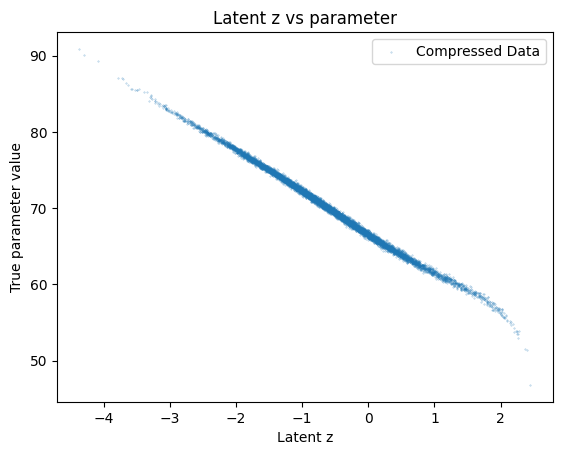

In [69]:
m, l, z = model.encoder(train_sims_data[:, :DATAPOINT_SIZE])
m = m.detach().cpu().numpy()

print(m.max(), m.min())

plt.scatter(m, train_sims_data[:, -1].cpu().numpy(), alpha=0.5, s=1e-1, label='Compressed Data')
plt.xlabel('Latent z')
plt.ylabel('True parameter value')
plt.legend()
# plt.xlim([110, 120])
plt.title('Latent z vs parameter')
plt.show()

In [55]:
# To check if the model collapsed: the standard deviations in m must match the priors
m.std(), l.std()


(np.float32(0.9202491),
 tensor(1.2619, device='cuda:0', grad_fn=<StdBackward0>))

Dataset size: 50000, Number of bins: 11, Bin width: 0.07
Bin centers: [-4.3785596  -3.7288957  -3.0792313  -2.4295673  -1.7799034  -1.1302394
 -0.4805752   0.16908884  0.81875277  1.4684167   2.1180809 ]
Bin means: [nan, 86.96625518798828, 83.28455352783203, 79.8768539428711, 76.50007629394531, 72.98414611816406, 69.29749298095703, 65.61504364013672, 62.36005401611328, 59.45724105834961, 55.246055603027344]
Bin stds: [nan, 0.2368471324443817, 0.2234818935394287, 0.24207018315792084, 0.24642883241176605, 0.24847538769245148, 0.2763271927833557, 0.2858603298664093, 0.2646122872829437, 0.30121955275535583, 0.3949034810066223]
Bin stds errors: [nan, np.float64(0.09669243692168698), np.float64(0.024098672341112185), np.float64(0.011593059214847752), np.float64(0.0069812388716363315), np.float64(0.004790791131045721), np.float64(0.004872654349306341), np.float64(0.006214354997095855), np.float64(0.009889025474431446), np.float64(0.018331638200636203), np.float64(0.04719999384248563)]


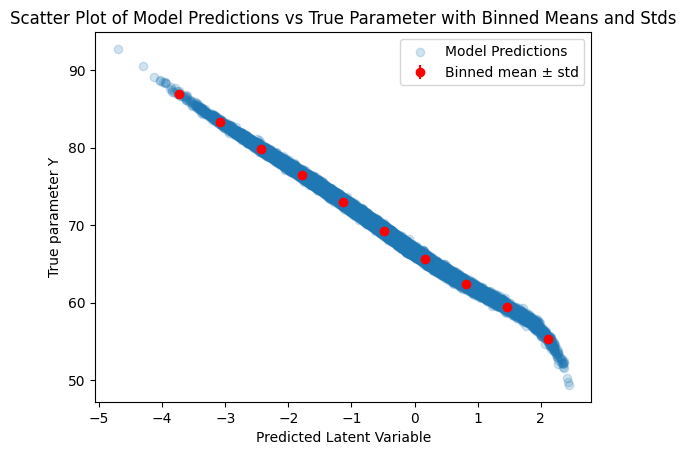

(np.float64(0.2639242938987307),
 array([0.23684713, 0.22348189, 0.24207018, 0.24642883, 0.24847539,
        0.27632719, 0.28586033, 0.26461229, 0.30121955, 0.39490348]),
 array([0.09669244, 0.02409867, 0.01159306, 0.00698124, 0.00479079,
        0.00487265, 0.00621435, 0.00988903, 0.01833164, 0.04719999]))

In [56]:
sigma_beta, _, std, std_err = evaluate_posterior_covariance(model, test_sims_data[:, :DATAPOINT_SIZE], test_sims_data[:, -1:])
sigma_beta, std, std_err

## Posterior comparison

In [57]:
SELECT_PERCENT = 1e-2

In [58]:
true_h0 = 80
# true_h0 = test_sims_data[0, -1].item()
_, data_obs, _, _ = create_synthetic_supernovae_dataset(n_samples=1, h0s=[true_h0])
data_obs = torch.tensor(data_obs, dtype=torch.float32).to(device)

y_data_abc = test_sims_data[:, -1:].detach().cpu()
shown_true_param = true_h0
param_name = '$H_0$'


Creating sample: 1 of 1


Compressed obs: -2.4821035861968994
Selected 169 samples from test set with compressed value close to observed compressed value.


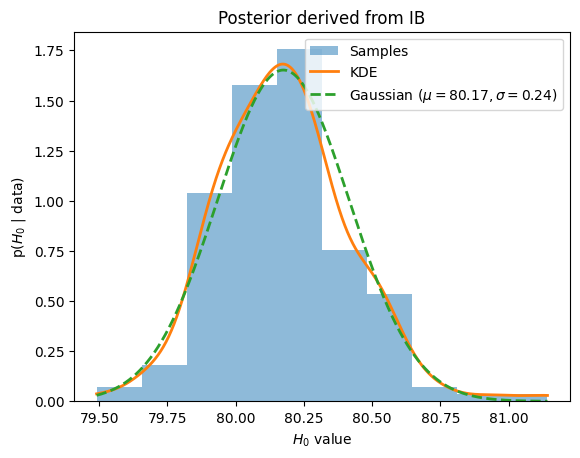

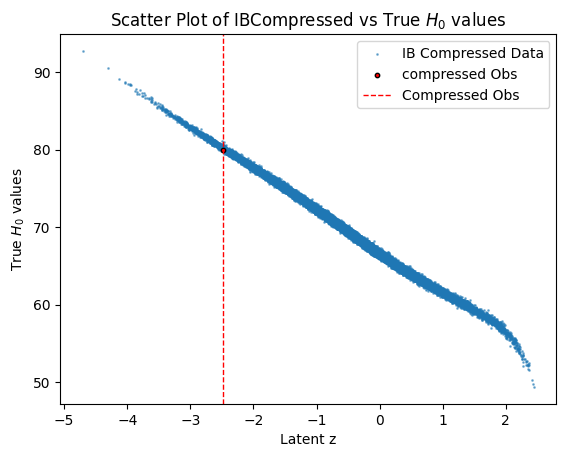

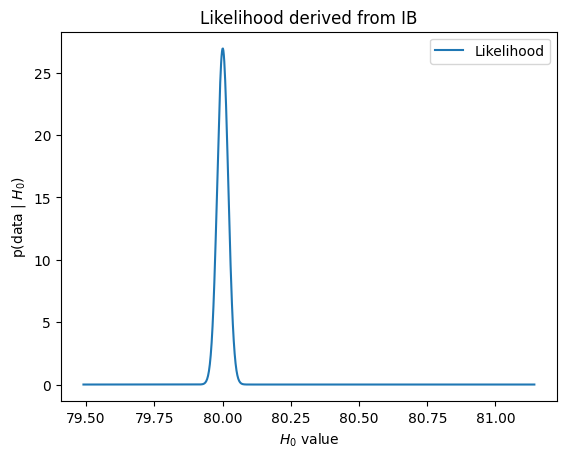

((np.float32(80.17474), np.float32(0.24150887)),
 0.7235496044158936,
 0.23668639053254437,
 169)

In [59]:
compressed_test = model(test_sims_data[:, :DATAPOINT_SIZE]).detach().cpu().numpy()

compressed_obs = model(data_obs).detach().cpu().numpy()

print("Compressed obs:", compressed_obs.item())

abc_testing(compressed_obs, compressed_test, 
            y_data=y_data_abc,
            true_param=shown_true_param,
            select_percent=SELECT_PERCENT,
            param_name=param_name,
            method_name='IB')

### MOPED Compression

Creating sample: 1 of 1
Creating sample: 1 of 1
Creating sample: 1 of 1
(1, 100)
MOPED Fisher information: [[625.]]


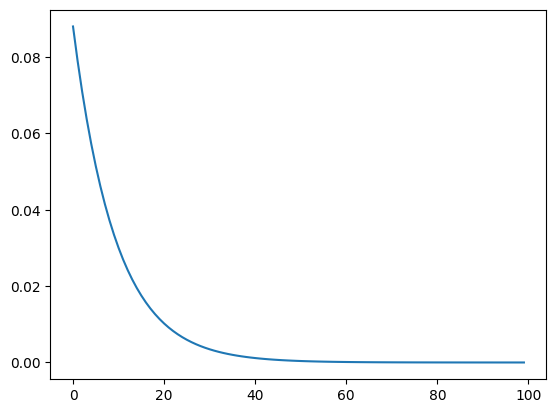

In [60]:
cov = np.eye(DATAPOINT_SIZE) * DATA_VARIANCE_SCALE**2

def estimator_given_theta(theta):
    _, data, _, _ = create_synthetic_supernovae_dataset(1, theta, data_var=0.)
    # print(data.shape)
    # return 10**(-0.4*data[0, :])
    return data[0, :]

fid_val = np.array([70.0])

b, F, d = moped(fid_val, cov, estimator_given_theta)
# print("MOPED compressed value:", b)
print("MOPED Fisher information:", 1/F)
plt.plot(b.T)
plt.show()

In [61]:
def moped_model(data):
    if (type(data) != np.ndarray):
        data = data.detach().cpu().numpy()
    return data[:, :DATAPOINT_SIZE] @ b.T
moped_compressed = moped_model(data_obs)
moped_test = moped_model(test_sims_data)
moped_compressed

array([[3.21258923]])

Selected 485 samples from test set with compressed value close to observed compressed value.


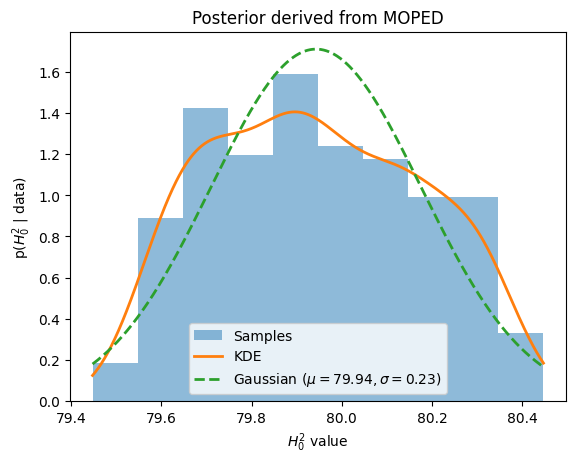

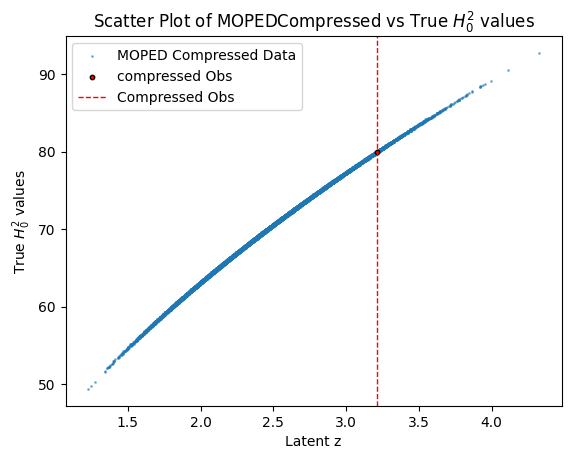

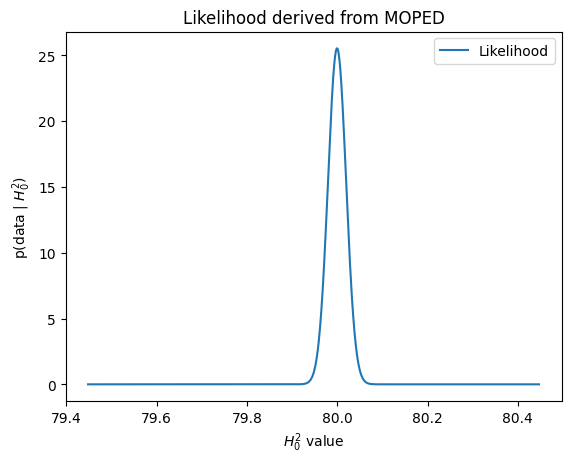

((np.float32(79.94292), np.float32(0.2333566)),
 0.24461759626865387,
 0.5979381443298969,
 485)

In [62]:
abc_testing(moped_compressed, moped_test, y_data_abc, select_percent=SELECT_PERCENT, true_param=shown_true_param)

# Coverage Testing

Creating sample: 5000 of 5000
Creating sample: 1 of 1


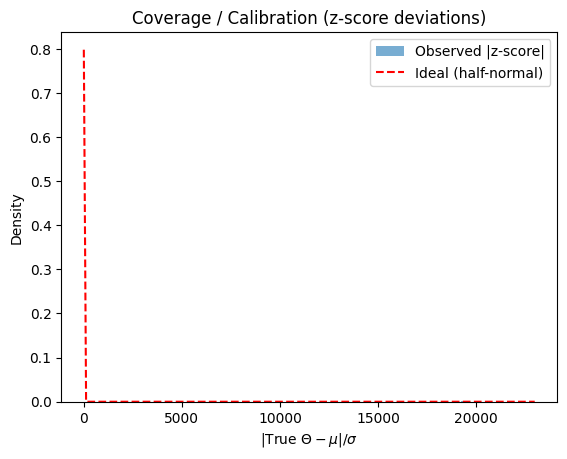

Fraction within 1σ: 0.000  (ideal ≈ 0.683)
Fraction within 2σ: 0.000  (ideal ≈ 0.954)


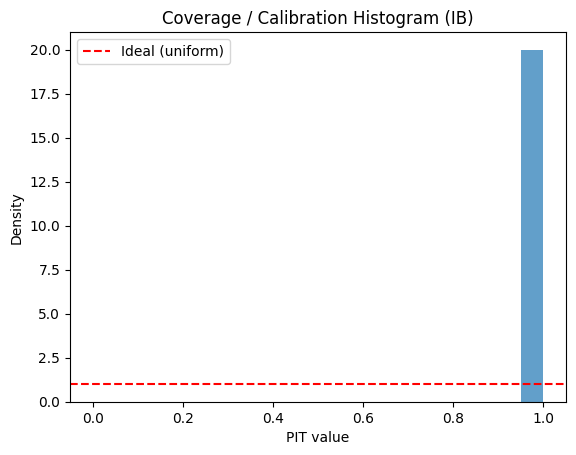

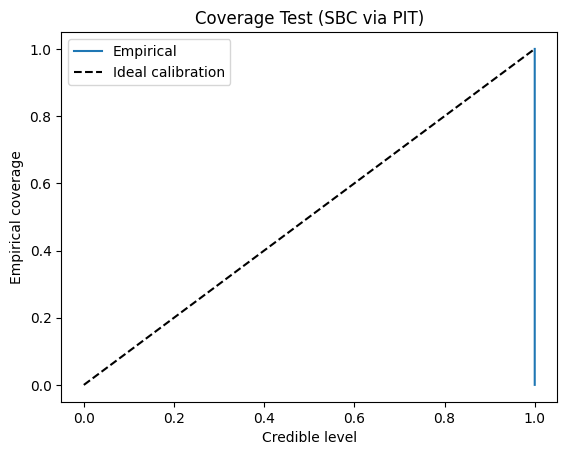

In [63]:
z_scores, pit_values= coverage_tests(5000, model, test_sims_data, "IB", select_percent=SELECT_PERCENT)

Creating sample: 1000 of 1000
Creating sample: 1 of 1


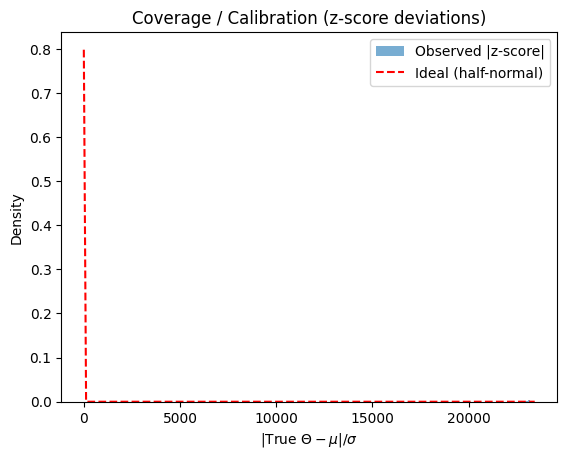

Fraction within 1σ: 0.000  (ideal ≈ 0.683)
Fraction within 2σ: 0.000  (ideal ≈ 0.954)


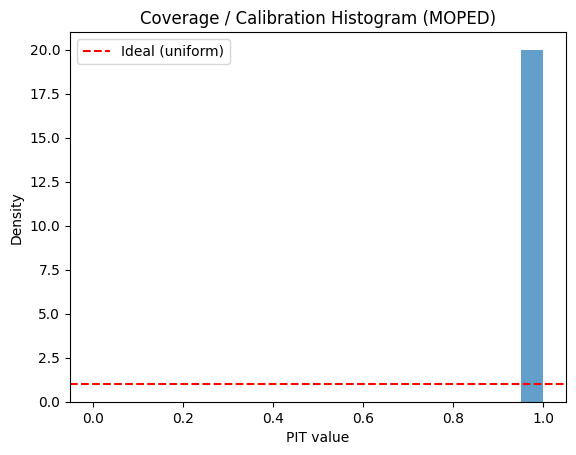

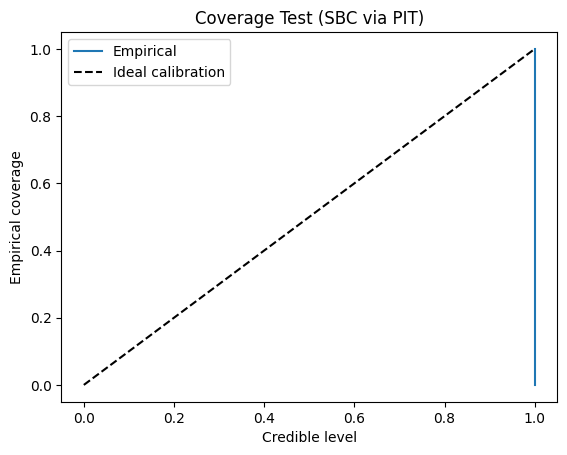

(array([23133.1796875 , 22998.0546875 , 23248.13867188, 23156.90234375,
        23169.984375  , 23188.4765625 , 22891.54882812, 22978.98242188,
        22893.04101562, 22937.3984375 , 23164.046875  , 22855.18945312,
        22901.55664062, 23077.48828125, 23109.62304688, 23086.3515625 ,
        23265.61523438, 23216.80859375, 23118.41015625, 23239.171875  ,
        23061.12890625, 23082.83398438, 23096.90039062, 23028.70703125,
        23178.33398438, 23016.16601562, 22827.09179688, 22898.4296875 ,
        22993.10351562, 22967.9453125 , 23166.79882812, 23080.19140625,
        23045.703125  , 23088.64453125, 22942.14648438, 23018.30859375,
        23007.38476562, 23071.95117188, 23147.61523438, 23124.6328125 ,
        23190.07617188, 22928.86523438, 22983.81054688, 22937.73046875,
        23161.40820312, 23163.265625  , 23194.875     , 23154.5625    ,
        23227.82226562, 23128.48046875, 23168.58007812, 22875.15234375,
        23160.42773438, 23153.27539062, 23069.08789062, 23161.41

In [64]:
coverage_tests(1000, moped_model, test_sims_data, "MOPED", select_percent=SELECT_PERCENT)